# Machine Learning Prediction of Ultimate Bearing Capacity of Shallow Foundations

## 1. Research Objective

The primary objective of this study is to develop a **machine learning (ML) model capable of predicting the ultimate bearing capacity of shallow foundations** using key soil and foundation parameters.

The model focuses on **soft clay and silty soils typical of the Niger Delta region**, where soil behavior is highly nonlinear and heterogeneous. Traditional analytical solutions often fail to capture the complex interaction between soil properties and foundation geometry. Therefore, data-driven models such as **Random Forest** are employed to improve prediction accuracy.

---


## 2. Motivation for Using Machine Learning

Classical bearing capacity theories such as those developed by Terzaghi (1943), Meyerhof (1963), Hansen (1970), and Vesic (1973) are widely used in foundation design. However, these methods are based on several simplifying assumptions:

- Soil is homogeneous and isotropic  
- Failure mechanism follows an idealized pattern  
- Soil behavior is linear or perfectly plastic  
- Groundwater effects are simplified  

In reality, **natural soils exhibit nonlinear stress–strain behavior and spatial variability**, especially in soft deltaic deposits such as those found in the Niger Delta.

Machine learning algorithms provide several advantages:

- Ability to capture **complex nonlinear relationships**  
- Incorporation of **multiple interacting soil parameters**  
- Improved prediction accuracy for **heterogeneous soils**  
- Reduction of empirical assumptions used in classical models  

Therefore, ML models can complement traditional geotechnical methods for predicting **ultimate bearing capacity**.

---

## Target Variable

#### Ultimate Bearing Capacity(qu)(kPa), 
This is what the model predicts.

#### Source
The dataset used in this study was obtained from geotechnical investigation reports provided by civil engineering consultancy firms involved in foundation design projects within the Niger Delta region of Nigeria. The data include laboratory-tested soil properties, foundation geometry, groundwater conditions, and corresponding bearing capacity values. All data were anonymized to ensure confidentiality and ethical compliance.

## 3. Feature Selection (Input Variables)

The predictive capability of any machine learning model strongly depends on the **selection of relevant input variables**. For shallow foundation bearing capacity prediction, the features can be categorized into three main groups:

1. Foundation geometry parameters  
2. Soil strength parameters  
3. Stress and groundwater parameters  

---

### 3.1 Foundation Geometry Parameters

#### 3.1.1 Foundation Width (B) (m)

**Definition:** Foundation width ($B$) is the horizontal dimension of a footing measured perpendicular to the direction of loading.  

**Influence on Bearing Capacity:** According to Terzaghi’s bearing capacity theory for strip footings:


$$
q_{ult} = c'N_c + \gamma D_f N_q + \frac{1}{2}\gamma B N_\gamma
$$

where  
$c'$ = effective cohesion  
$\gamma$ = unit weight of soil  
$D_f$ = foundation depth  
$N_c, N_q, N_\gamma$ = bearing capacity factors  

The term $\frac{1}{2}\gamma B N_\gamma$ shows that ultimate capacity increases with width.  

The third term shows that **ultimate bearing capacity increases with foundation width** due to the increased shear resistance mobilized beneath the footing.

#### For Purely Cohesive Soil ($\phi = 0$)

$$
q_{ult} = 5.14 C_u
$$

In this case, $B$ does not directly affect $q_{ult}$, but it affects total load capacity.

---

#### Load-Carrying Capacity

Total ultimate load:

$$
Q_{ult} = q_{ult} \times B \times L
$$

For strip footing (per unit length):

$$
Q_{ult} = q_{ult} \times B
$$

Thus, increasing $B$ increases total load capacity.

---

#### Settlement Consideration

Settlement generally increases with foundation width because:

- Stress influence zone increases  
- Larger soil volume is compressed  

Approximate stress influence depth:

$$
z \approx 1.5B \text{ to } 2B
$$

---


#### Key Points
- Measured in meters (m)
- Directly affects stress distribution
- Increasing $B$ increases total load capacity
- Must balance bearing capacity and settlement requirements


**Engineering Significance:**  


- Controls bearing capacity
- Influences settlement magnitude
- Affects stress distribution in soil
- Key design variable in shallow foundations


---


#### 3.1.2 Foundation Depth (Df) (m)

**Definition:** Foundation depth ($D_f$) is the vertical distance from the ground surface to the base of the foundation.

**Influence on Bearing Capacity:** Increasing embedment depth improves bearing capacity because the soil above the foundation contributes **additional confining pressure**:

#### Bearing Capacity Influence

For a strip footing (Terzaghi’s theory):

$$
q_{ult} = c'N_c + \gamma D_f N_q + \frac{1}{2}\gamma B N_\gamma
$$

where  
$c'$ = effective cohesion  
$\gamma$ = unit weight of soil  
$B$ = foundation width  
$N_c, N_q, N_\gamma$ = bearing capacity factors  

- The term $\gamma D_f N_q$ shows that **bearing capacity increases with depth**.  
- Deeper foundations mobilize greater soil resistance.

---

#### Settlement Consideration

- Deeper foundations generally reduce settlement because:
  - Stresses are applied to denser, stronger soil layers
  - Surface soil compressibility has less effect

Approximate stress influence depth:

$$
z \approx 1.5B \text{ to } 2B
$$

---

#### Engineering Significance

- Influences **ultimate bearing capacity**  
- Reduces settlement in compressible soils  
- Determines frost protection in cold regions  
- Impacts excavation depth and construction cost  

---

#### Key Points
- Measured in meters (m)  
- Greater $D_f$ → higher bearing capacity and reduced settlement  
- Must balance cost and geotechnical requirements  
- Critical for shallow foundation design


**Engineering Significance:**  

- Mobilizes higher confining stress  
- Increases shear resistance of soil  
- Improves overall bearing capacity  

---

#### 3.1.3 Shape Factor (s)

**Definition:** The shape factor accounts for the effect of **foundation geometry** on the ultimate bearing capacity. Footings may be: strip, square, circular, or rectangular.

#### Bearing Capacity Equation (Terzaghi’s Theory)

For a general footing:

$$
q_{ult} = s_c c' N_c + s_q \gamma D_f N_q + \frac{1}{2} s_\gamma \gamma B N_\gamma
$$

Where:  
- $s_c, s_q, s_\gamma$ = shape factors for cohesion, surcharge, and unit weight terms  
- $c'$ = effective cohesion  
- $\gamma$ = unit weight of soil  
- $B$ = foundation width  
- $D_f$ = foundation depth  
- $N_c, N_q, N_\gamma$ = bearing capacity factors  

---

**Typical Shape Factor Values:**

| Footing Type | \(s_c\) | \(s_q\) | \(s_\gamma\) |
|--------------|---------|---------|--------------|
| Strip        | 1.0     | 1.0     | 1.0          |
| Square       | 1.3     | 1.2     | 0.8          |
| Circular     | 1.3     | 1.2     | 0.6          |
| Rectangular  | 1.0–1.3 | 1.0–1.2 | 0.8–1.0      |

---


## 3.2 Soil Properties


#### 3.2.1 Undrained Shear Strength ($C_u$) (kPa)

#### Definition
Undrained shear strength, $C_u$, is the maximum shear stress a fully saturated cohesive soil (usually clay) can resist under **undrained (no drainage)** conditions.  
It represents the **short-term shear strength** of clay in total stress analysis.

$$
\tau_f = C_u
$$

Under undrained loading:
$$
\phi_u = 0^\circ
$$


This is known as $\phi = 0$ analysis.

---

#### Physical Meaning
During rapid loading:
- No volume change occurs  
- Excess pore water pressure develops  
- Effective stress changes internally  
- Failure occurs when shear stress reaches $C_u$

Thus, $C_u$ governs **immediate stability** before consolidation.

---

#### Determination

1. **Unconfined Compression Test (UCC):**
$$
C_u = \frac{q_u}{2}
$$


2. **Triaxial UU Test**  
3. **Field tests:** Vane shear, CPT correlations

---

#### Typical Values

| Consistency | $C_u$ (kPa) |
|-------------|-------------|
| Very soft   | < 25 |
| Soft        | 25–50 |
| Medium      | 50–100 |
| Stiff       | 100–200 |

---

#### Engineering Use

1. **Bearing Capacity (short-term):**
$$
q_{ult} = 5.14 C_u
$$

2. **Slope Stability**
3. **Embankments on soft clay**

---

#### Important Notes
- Used for **short-term, rapid loading**
- Applies to **fully saturated clay**
- Not suitable for long-term drained conditions
- $C_u$ depends on stress history and OCR

$$
C_u \approx (0.2 - 0.3)\sigma'_v
$$


#### 3.2.2 Bulk Unit Weight ($\gamma$) (kN/m³)

#### Definition
Bulk unit weight, $\gamma$, is the total weight of soil per unit total volume, including:
- Soil solids
- Water
- Air

It represents the in-situ weight of soil mass.

$$
\gamma = \frac{W}{V}
$$

where  
$W$ = total weight of soil (kN)  
$V$ = total volume (m³)

---

#### Relation with Density

$$
\gamma = \rho g
$$

where  
$\rho$ = bulk density (kg/m³)  
$g$ = acceleration due to gravity (9.81 m/s²)

---

#### Soil Phase Relationship

Total weight:

$$
W = W_s + W_w
$$

Total volume:

$$
V = V_s + V_v
$$

where  
$s$ = solids  
$w$ = water  
$v$ = voids  

Thus, $\gamma$ depends on:
- Moisture content  
- Void ratio  
- Degree of saturation  

---

#### Special Forms

Dry unit weight:

$$
\gamma_d = \frac{W_s}{V}
$$

Saturated unit weight:

$$
\gamma_{sat}
$$

Submerged (effective) unit weight:

$$
\gamma' = \gamma_{sat} - \gamma_w
$$

where $\gamma_w$ = unit weight of water.

---

#### Vertical Stress Application

$$
\sigma_v = \gamma z
$$

where  
$\sigma_v$ = vertical overburden stress  
$z$ = depth  

---

#### Typical Values

| Soil Type | $\gamma$ (kN/m³) |
|------------|----------------|
| Loose sand | 15–17 |
| Dense sand | 18–20 |
| Soft clay | 14–18 |
| Stiff clay | 18–21 |

---

#### Key Points
- Includes solids + water + air
- Controls overburden stress
- State-dependent (moisture and compaction)
- Fundamental for bearing capacity and settlement analysis


#### 3.2.3 Plasticity Index (PI, \%)

#### Definition
Plasticity Index (PI) is the range of water content over which a soil behaves plastically.

It indicates the degree of plasticity and clay activity in fine-grained soils.

$$
PI = LL - PL
$$

where  
$LL$ = Liquid Limit (%)  
$PL$ = Plastic Limit (%)

---

#### Physical Meaning

- At water content > $LL$: soil behaves like a liquid  
- At water content < $PL$: soil behaves like a semi-solid  
- Between $PL$ and $LL$: soil is plastic  

Thus, $PI$ represents the width of the plastic range.

---

#### Engineering Significance

- Indicates clay content and mineralogy  
- Higher $PI$ → higher compressibility and swelling potential  
- Higher $PI$ → lower permeability  
- Strongly influences shear strength and settlement behavior  

---

#### Classification (Typical Ranges)

| PI (%) | Soil Description |
|--------|------------------|
| 0–7    | Low plasticity |
| 7–17   | Medium plasticity |
| >17    | High plasticity |

---

#### Relation to Activity

Clay activity:

$$
A = \frac{PI}{\% \text{ clay fraction}}
$$

Higher activity → more expansive clay minerals (e.g., montmorillonite).

---

#### Key Points
- $PI$ measures plastic behavior range  
- Used in soil classification (Atterberg limits)  
- Important for predicting swelling, compressibility, and strength  
- Higher $PI$ generally indicates more problematic clay

#### Liquid Limit (LL, \%)

#### Definition
Liquid Limit (LL) is the water content at which a soil changes from the plastic state to the liquid state.

It represents the water content at which soil begins to flow under a standard loading condition.

---

#### Determination (Casagrande Method)

Liquid Limit corresponds to the water content at:

$$
N = 25 \text{ blows}
$$

where  
$N$ = number of blows required to close a standard groove over a distance of 12.7 mm.

---

#### Flow Curve Relationship

The relationship between water content and number of blows is:

$$
w = a - b \log N
$$

where  
$w$ = water content (%)  
$N$ = number of blows  
$a, b$ = empirical constants  

LL is obtained from the flow curve at $N = 25$.

---

#### Physical Meaning

- At $w > LL$: soil behaves like a viscous liquid  
- At $w < LL$: soil behaves plastically  
- Higher $LL$ indicates higher clay content and compressibility  

---

#### Engineering Significance

- Used in soil classification (Atterberg limits)  
- Indicates compressibility and swelling potential  
- Correlates with shear strength and settlement behavior  
- High $LL$ soils generally have low permeability  

---

#### Typical Ranges

| LL (\%) | Soil Type |
|----------|-----------|
| < 35     | Low plasticity clay |
| 35–50    | Medium plasticity clay |
| > 50     | High plasticity clay |

---

#### Key Points
- $LL$ is a consistency limit  
- Determined at 25 blows (Casagrande apparatus)  
- Increases with clay mineral activity  
- Strong indicator of soil compressibility

#### 3.2.4 Natural Water Content ($w$) (\%)

#### Definition
Natural water content, $w$, is the ratio of the weight of water in a soil sample to the weight of dry soil solids, expressed as a percentage.

It represents the in-situ moisture condition of the soil.

$$
w = \frac{W_w}{W_s} \times 100
$$

where  
$W_w$ = weight of water  
$W_s$ = weight of dry soil solids  

---

#### Determination (Oven-Drying Method)

1. Weigh moist soil: $W_{moist}$  
2. Oven dry at 105–110$^\circ$C for 24 hours  
3. Weigh dry soil: $W_{dry}$  

Water content is computed as:

$$
w = \frac{W_{moist} - W_{dry}}{W_{dry}} \times 100
$$

---

#### Physical Meaning

- High $w$ → soil contains more pore water  
- Low $w$ → soil is relatively dry  
- Influences strength, compressibility, and consistency  

For clays, $w$ strongly affects undrained shear strength.

---

#### Engineering Significance

- Used to compute:
  - Void ratio  
  - Degree of saturation  
  - Unit weight  
- Helps determine soil state relative to Atterberg limits  
- Important for compaction control and settlement analysis  

---

#### Relation to Liquidity Index

$$
LI = \frac{w - PL}{PI}
$$

where  
$PL$ = Plastic Limit  
$PI$ = Plasticity Index  

$LI$ indicates the current consistency state of clay.

---

#### Typical Values

| Soil Type | $w$ (\%) |
|-----------|----------|
| Sand      | 5–15 |
| Silt      | 10–30 |
| Clay      | 20–70+ |

---

#### Key Points
- Expressed as a percentage  
- State-dependent parameter  
- Directly influences strength and deformation behavior  
- Essential input in geotechnical modeling

## 3.3 Stress & Groundwater Parameters

#### 3.3.1 Overburden Pressure at Foundation Level ($\sigma'_v$) (kPa)

#### Definition
Overburden pressure, $\sigma'_v$, is the **vertical effective stress** at the foundation base due to the weight of the soil above.

It represents the stress transmitted by the soil to deeper layers and controls settlement and bearing capacity.

---

#### Calculation

For a homogeneous soil layer:

$$
\sigma'_v = \gamma \, D_f
$$

where:  
- $\gamma$ = bulk unit weight of soil (kN/m³)  
- $D_f$ = foundation depth (m)  

---

#### For Multiple Soil Layers

$$
\sigma'_v = \sum_{i=1}^{n} \gamma_i \, h_i
$$

where:  
- $h_i$ = thickness of layer $i$  
- $\gamma_i$ = bulk unit weight of layer $i$  

---

#### 3.3.2 Effective Stress Concept

- Effective stress accounts for **pore water pressure**:  

$$
\sigma'_v = \sigma_v - u
$$

where:  
- $\sigma_v$ = total vertical stress  
- $u$ = pore water pressure  

- For saturated soils below water table:  

$$
\sigma'_v = \gamma_{sat} D_f - \gamma_w h_w
$$

where $h_w$ = depth of submerged soil layer.

---

#### Engineering Significance

- Governs **shear strength mobilization**  
- Used in **bearing capacity calculations**  
- Influences **settlement prediction**  
- Determines **stress-dependent soil properties**  

---

#### Key Points
- Units: kPa  
- Directly proportional to depth and soil unit weight  
- Must consider water table for effective stress  
- Essential input in foundation and geotechnical analysis

#### 3.3.3 Groundwater Table Depth ($h_{gw}$) (m)

#### Definition
Groundwater table depth, $h_{gw}$, is the vertical distance from the ground surface to the **water table**, the level below which the soil pores are fully saturated.

It controls pore pressure, effective stress, and seepage effects on foundations.

---

#### Engineering Considerations

1. **Effective Stress Adjustment**

For soils below the water table:

$$
\sigma'_v = \sigma_v - u = \gamma D_f - \gamma_w h_{sub}
$$

where:  
- $\sigma_v$ = total vertical stress (kPa)  
- $u$ = pore water pressure (kPa)  
- $h_{sub}$ = thickness of saturated soil layer (m)  
- $\gamma_w$ = unit weight of water (9.81 kN/m³)  

2. **Buoyancy Effect**

Submerged unit weight:

$$
\gamma' = \gamma_{sat} - \gamma_w
$$

Reduces the stress transmitted to soil below water table.

---

#### Impact on Foundations

- Shallow groundwater → reduces effective stress → lower bearing capacity  
- Influences **settlement**, **pore pressure**, and **liquefaction risk**  
- Important for drainage design during construction  

---

#### Key Points
- Measured in meters (m) from ground surface  
- Must be considered in **bearing capacity and settlement calculations**  
- Affects effective stress distribution and soil strength  
- Essential input for geotechnical modeling

## Data Preparation




##### 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### 2. Load Dataset
df = pd.read_csv('your_dataset.csv')

##### 3. Check Missing Values
df.isnull().sum()

##### 4. Descriptive Statistics
df.describe()

##### 5. Correlation Analysis
df.corr()


In [2]:

# importing the required libaries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import io
import requests
import seaborn as sns
import re
from scipy.stats import skew

# Function to clean a string and extract numeric value
def clean_numeric(value):
    if isinstance(value, str):
        # Remove all non-numeric characters except dot and minus sign
        value = re.sub(r'[^\d\.-]', '', value)
    return pd.to_numeric(value, errors='coerce')

# Loop through all object columns in the dataset

def statsdescribe(df):
    
    stats = pd.DataFrame({
    "Mean": df.mean(),
    "Std Dev": df.std(),
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Skewness": df.apply(skew)
})
    print(stats)

# Check results





def Getdataset(url):
    # 1. Put your Google Drive shareable link here
    url = "https://drive.google.com/file/d/1JBBvSbYDgYszeOufqjcGOa2aLVaDqskK/view?usp=drivesdk"

    # 2. Convert the shareable link to a direct download link
    # Replace "file/d/FILE_ID/view?usp=sharing" with "uc?export=download&id=FILE_ID"
    file_id = url.split('/d/')[1].split('/')[0]
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    # 3. Download the file
    response = requests.get(download_url)
    response.raise_for_status()  # make sure it downloaded correctly
    # 4. Read CSV robustly
    df = pd.read_csv(io.StringIO(response.text), 
                 sep=',',        # change if your file uses tabs: sep='\t'
                 header=None,    # treat every row as data, no headers
                 on_bad_lines='skip')  # skip lines that break the parser
    # 5. Check the first few rows
    

    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].apply(clean_numeric)

    print(df.head())
   
    print(df.dtypes)

    return df
    print(df.head())
    # 6. Optional: save a cleaned version
    # df.to_csv("cleaned_file.csv", index=False)

    






# def ChangeToNumerical(dataset):
#     # Loop through all columns
#     for col in dataset.columns:
#     if dataset[col].dtype == 'object':
#         dataset[col] = pd.to_numeric(df[col], errors='coerce')
#     # Check data types after conversion
#     print(df.dtypes)
#     return dataset

def NameColumns(dataset):
    column_name = ["Natural water content(%)","Liquid Limit(%)",
                   "Plasticity Index(%)","Bulk unit weight","Undrained shear strength,Cu(kpa)",
                   "Overburden pressure at foundation level(kpa)","Foundation width(m)","Foundation depth(m)",
                   "shape factor", "Groundwater table depth below ground(m)", "Ultimate bearing capacity,qu(kpa)"]
    dataset.columns = column_name
    dataset.drop(dataset.index[0], inplace = True)
    return dataset
    
    
    

In [3]:
link_to_dataset = "https://drive.google.com/file/d/1JBBvSbYDgYszeOufqjcGOa2aLVaDqskK/view?usp=drivesdk"
dataset = Getdataset(link_to_dataset)


          0          1          2          3           4          5   \
0        NaN        NaN        NaN        NaN         NaN        NaN   
1  54.981605  63.085284  33.785387  17.944771  115.033490  62.309715   
2  78.028572  62.348940  27.213132  16.517159  110.910376  56.607693   
3  69.279758  95.312729  61.308706  18.617184   36.969275  34.661548   
4  63.946339  62.477310  43.629812  17.839349  140.321551  95.017334   

         6         7    8         9           10  
0       NaN       NaN  NaN       NaN         NaN  
1  2.135766  0.609763  1.0  1.225487  656.543650  
2  0.700081  0.634218  0.7  1.447292  429.679443  
3  1.105825  1.477961  0.7  1.628849  175.336603  
4  2.434198  1.230411  0.7  3.418561  592.658311  
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
dtype: object


In [4]:
NameColumns(dataset)

,Natural water content(%),Liquid Limit(%),Plasticity Index(%),Bulk unit weight,"Undrained shear strength,Cu(kpa)",Overburden pressure at foundation level(kpa),Foundation width(m),Foundation depth(m),shape factor,Groundwater table depth below ground(m),"Ultimate bearing capacity,qu(kpa)"
1,54.981605,63.085284,33.785387,17.944771,115.033490,62.309715,2.135766,0.609763,1.0,1.225487,656.543650
2,78.028572,62.348940,27.213132,16.517159,110.910376,56.607693,0.700081,0.634218,0.7,1.447292,429.679443
3,69.279758,95.312729,61.308706,18.617184,36.969275,34.661548,1.105825,1.477961,0.7,1.628849,175.336603
4,63.946339,62.477310,43.629812,17.839349,140.321551,95.017334,2.434198,1.230411,0.7,3.418561,592.658311
5,46.240746,63.597486,44.866250,16.471612,96.059025,76.727382,1.821715,1.685623,0.8,3.577543,455.013215
...,...,...,...,...,...,...,...,...,...,...,...
1996,66.278206,72.105352,39.994468,16.819479,132.206999,10.650228,1.560845,0.511387,1.0,2.574012,677.022010
1997,78.264585,66.720059,39.139549,16.628558,137.188604,132.313612,2.789228,1.359006,0.7,3.594168,586.886061
1998,42.758321,69.728616,35.599895,17.365986,143.338489,53.025525,1.744845,1.575780,0.8,2.379964,680.506507
1999,42.282189,76.497029,49.364763,18.725313,74.685999,141.402440,1.497092,1.617620,0.8,3.178699,422.842765


In [4]:
dataset.head()

,Natural water content(%),Liquid Limit(%),Plasticity Index(%),Bulk unit weight,"Undrained shear strength,Cu(kpa)",Overburden pressure at foundation level(kpa),Foundation width(m),Foundation depth(m),shape factor,Groundwater table depth below ground(m),"Ultimate bearing capacity,qu(kpa)"
1,54.981605,63.085284,33.785387,17.944771,115.033490,62.309715,2.135766,0.609763,1.0,1.225487,656.543650
2,78.028572,62.348940,27.213132,16.517159,110.910376,56.607693,0.700081,0.634218,0.7,1.447292,429.679443
3,69.279758,95.312729,61.308706,18.617184,36.969275,34.661548,1.105825,1.477961,0.7,1.628849,175.336603
4,63.946339,62.477310,43.629812,17.839349,140.321551,95.017334,2.434198,1.230411,0.7,3.418561,592.658311
5,46.240746,63.597486,44.866250,16.471612,96.059025,76.727382,1.821715,1.685623,0.8,3.577543,455.013215


In [5]:
import seaborn as sns
print(dataset.isnull().sum())

missing_percent = dataset.isnull().mean() * 100
print(missing_percent)

# sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
# plt.title("Missing Values Heatmap")
# plt.show()
# The dataset has no missing value

Natural water content(%)                        0
Liquid Limit(%)                                 0
Plasticity Index(%)                             0
Bulk unit weight                                0
Undrained shear strength,Cu(kpa)                0
Overburden pressure at foundation level(kpa)    0
Foundation width(m)                             0
Foundation depth(m)                             0
shape factor                                    0
Groundwater table depth below ground(m)         0
Ultimate bearing capacity,qu(kpa)               0
dtype: int64
Natural water content(%)                        0.0
Liquid Limit(%)                                 0.0
Plasticity Index(%)                             0.0
Bulk unit weight                                0.0
Undrained shear strength,Cu(kpa)                0.0
Overburden pressure at foundation level(kpa)    0.0
Foundation width(m)                             0.0
Foundation depth(m)                             0.0
shape factor         

In [6]:
dataset.describe()

,Natural water content(%),Liquid Limit(%),Plasticity Index(%),Bulk unit weight,"Undrained shear strength,Cu(kpa)",Overburden pressure at foundation level(kpa),Foundation width(m),Foundation depth(m),shape factor,Groundwater table depth below ground(m),"Ultimate bearing capacity,qu(kpa)"
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,59.945477,74.819519,47.412397,17.463519,86.455730,80.766030,1.738799,1.246913,0.826600,2.789852,452.356215
std,11.688432,14.428995,16.026036,0.861943,35.271287,40.779190,0.727037,0.435446,0.121983,0.954916,169.517936
min,40.128731,50.000582,10.515223,16.000723,25.006603,10.022084,0.503009,0.500465,0.700000,0.626941,115.541896
25%,49.521859,62.539338,34.961698,16.717990,56.657791,45.401733,1.093861,0.866963,0.700000,2.045893,314.120970
50%,60.294051,74.634716,46.956869,17.452596,85.837979,80.450643,1.719702,1.244298,0.800000,2.776414,442.784638
75%,70.027153,87.434525,60.057248,18.211401,116.210465,116.781827,2.382380,1.638869,1.000000,3.509396,561.561530
max,79.988707,99.977885,84.596287,18.998382,149.938149,149.954249,2.997112,1.999887,1.000000,4.983709,948.567410


In [116]:
statsdescribe(dataset)

                                                    Mean     Std Dev  \
Natural water content(%)                       59.945477   11.688432   
Liquid Limit(%)                                74.819519   14.428995   
Plasticity Index(%)                            47.412397   16.026036   
Bulk unit weight                               17.463519    0.861943   
Undrained shear strength,Cu(kpa)               86.455730   35.271287   
Overburden pressure at foundation level(kpa)   80.766030   40.779190   
Foundation width(m)                             1.738799    0.727037   
Foundation depth(m)                             1.246913    0.435446   
shape factor                                    0.826600    0.121983   
Groundwater table depth below ground(m)         2.789852    0.954916   
Ultimate bearing capacity,qu(kpa)             452.356215  169.517936   

                                                 Minimum     Maximum  Skewness  
Natural water content(%)                       40.1287

In [35]:
dataset.skew()

0    -0.010167
1     0.004309
2     0.001916
3     0.062480
4     0.035328
5    -0.023936
6     0.052322
7    -0.012325
8     0.487956
9     0.068183
10    0.392101
dtype: float64

In [117]:
dataset.head()

,Natural water content(%),Liquid Limit(%),Plasticity Index(%),Bulk unit weight,"Undrained shear strength,Cu(kpa)",Overburden pressure at foundation level(kpa),Foundation width(m),Foundation depth(m),shape factor,Groundwater table depth below ground(m),"Ultimate bearing capacity,qu(kpa)"
1,54.981605,63.085284,33.785387,17.944771,115.033490,62.309715,2.135766,0.609763,1.0,1.225487,656.543650
2,78.028572,62.348940,27.213132,16.517159,110.910376,56.607693,0.700081,0.634218,0.7,1.447292,429.679443
3,69.279758,95.312729,61.308706,18.617184,36.969275,34.661548,1.105825,1.477961,0.7,1.628849,175.336603
4,63.946339,62.477310,43.629812,17.839349,140.321551,95.017334,2.434198,1.230411,0.7,3.418561,592.658311
5,46.240746,63.597486,44.866250,16.471612,96.059025,76.727382,1.821715,1.685623,0.8,3.577543,455.013215


From the table above,the dataset contains 2000 observations with no missing values. The descriptive statistics indicate that the variables are reasonably distributed, with mean values lying between the minimum and maximum limits. The quartile values (Q1, median, Q3) suggest a fairly symmetric distribution for most variables. The standard deviation values indicate moderate variability within the dataset.

In [9]:
dataset.corr()

,Natural water content(%),Liquid Limit(%),Plasticity Index(%),Bulk unit weight,"Undrained shear strength,Cu(kpa)",Overburden pressure at foundation level(kpa),Foundation width(m),Foundation depth(m),shape factor,Groundwater table depth below ground(m),"Ultimate bearing capacity,qu(kpa)"
Natural water content(%),1.000000,0.003835,-0.011182,0.037950,-0.052628,0.007585,0.008399,0.014810,-0.020887,-0.002093,-0.057008
Liquid Limit(%),0.003835,1.000000,0.893469,-0.025209,-0.000785,0.026571,-0.021941,-0.006370,-0.008104,-0.020650,-0.001675
Plasticity Index(%),-0.011182,0.893469,1.000000,-0.030004,-0.006472,0.042599,-0.029439,0.004181,0.004758,-0.025176,0.003907
Bulk unit weight,0.037950,-0.025209,-0.030004,1.000000,-0.004135,0.044158,0.025295,-0.000837,-0.002876,0.000885,0.008087
"Undrained shear strength,Cu(kpa)",-0.052628,-0.000785,-0.006472,-0.004135,1.000000,-0.041787,0.008843,-0.022096,0.005153,0.006062,0.876579
Overburden pressure at foundation level(kpa),0.007585,0.026571,0.042599,0.044158,-0.041787,1.000000,0.031075,-0.020540,0.027249,-0.001672,0.172107
Foundation width(m),0.008399,-0.021941,-0.029439,0.025295,0.008843,0.031075,1.000000,-0.006475,-0.018118,0.020764,0.003675
Foundation depth(m),0.014810,-0.006370,0.004181,-0.000837,-0.022096,-0.020540,-0.006475,1.000000,0.013759,0.471016,0.016934
shape factor,-0.020887,-0.008104,0.004758,-0.002876,0.005153,0.027249,-0.018118,0.013759,1.000000,-0.026231,0.412573
Groundwater table depth below ground(m),-0.002093,-0.020650,-0.025176,0.000885,0.006062,-0.001672,0.020764,0.471016,-0.026231,1.000000,0.010101


The correlation matrix indicates that most variables exhibit weak linear relationships. However, strong positive correlations were observed between Variable 1(Liquid limit) and Variable 2(Plasticty Index) (r = 0.893) and between Variable 4(Undrained shear Strength) and Variable 10(Ultimate bearing Capacity) (r = 0.877), suggesting potential multicollinearity. These relationships were considered during feature selection for modeling.

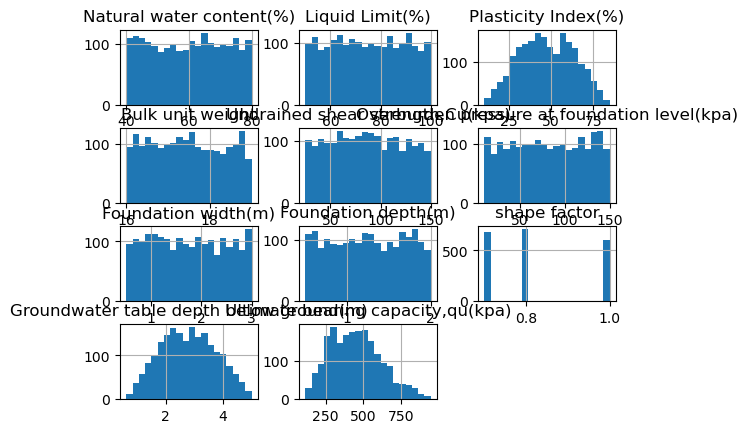

In [10]:
# Select only numerical columns
numeric_cols = dataset.select_dtypes(include=['int64', 'float64'])

# Plot histograms
numeric_cols.hist(bins=20)

plt.show()

Histograms were plotted for all numerical variables to examine their distribution patterns. Most variables exhibit approximately symmetric or uniformly distributed patterns, with no extreme skewness or significant outliers observed. One variable showed discrete value characteristics, indicating a categorical or bounded parameter. Overall, the dataset demonstrates stable statistical behavior suitable for modeling.

### Data Pre-Processing

In [5]:
#importing the required libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

#### Feature - Target split

In [6]:
# dataset.drop(dataset.index[0], inplace = True)
features = dataset.iloc[:,:-1]
Target = dataset.iloc[:,-1]

#### Train -test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    features, Target, test_size=0.2, random_state=42
)


#### Feature Scaling

Feature scaling was performed to standardize the range of independent variables. This ensures that no single feature dominates the model due to differences in magnitude. Standardization (Z-score normalization) was applied prior to model training.

In this study, the input variables such as depth (m), undrained shear strength (kPa), unit weight (kN/m$^3$), and other geotechnical parameters have different value ranges. For example:


    1. Depth may range from 1 to 20 m
    2. Undrained shear strength may range from 10 to 100 kPa
    3. Bearing capacity may range from 100 to 1000 kPa


Without scaling, variables with larger numerical values (e.g., bearing capacity) could disproportionately influence machine learning models.

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Machine Learning Model Development

##### Random Forest Model

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [106]:
X_test[0]

array([ 0.96047101,  1.14122312,  1.08924235, -1.48033565,  1.26538751,
        1.40031357, -0.64445977, -1.41154147,  1.43450707, -1.75748766])

In [103]:
print(y_pred[5])

410.7882039372583


In [104]:
print(y_test.values[5])

438.1243790391399


A Random Forest Regressor was implemented to model the relationship between the input features and the target variable. The model constructs an ensemble of decision trees, each trained on a random subset of the data and features. The predictions from all trees are aggregated by averaging to produce the final output. This method helps reduce overfitting and improves the model’s generalization performance.
Random Forest was chosen over other regression methods because it handles both linear and nonlinear relationships, is robust to outliers and noise, and automatically captures feature interactions without requiring extensive preprocessing. Compared to methods like linear regression or single decision trees, Random Forest provides higher accuracy and stability, especially for complex datasets.

## Model Evaluation

#### Model Validation Techniques

---

#### 1. Mean Absolute Error (MAE)

**Definition:**  
MAE measures the average magnitude of errors between predicted and actual values.

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
$$

**Interpretation:**  
- Lower MAE indicates a better model.  
- All errors are treated equally; large errors are not emphasized.

**Use case:**  
Useful when you want a simple average error measure without penalizing outliers.

---

#### 2. Root Mean Squared Error (RMSE)

**Definition:**  
RMSE measures the square root of the average squared differences between predicted and actual values.

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

**Interpretation:**  
- Penalizes large errors more than small errors.  
- Lower RMSE indicates a better model fit.

**Use case:**  
Useful when large prediction errors are particularly undesirable.

---

#### 3. Coefficient of Determination (R²)

**Definition:**  
R² indicates how well the model explains the variability of the target data.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

where $\bar{y}$ is the mean of actual values.

**Interpretation:**  
- R² ranges from 0 to 1; higher values indicate better fit.  
- $R^2 = 0.8$ means the model explains 80\% of the variance in the data.

**Use case:**  
Good for evaluating overall goodness of fit in regression models.

---

#### Quick Comparison

| Metric | Sensitive to Outliers? | What it Tells You |
|--------|----------------------|-----------------|
| MAE    | No                   | Average prediction error |
| RMSE   | Yes                  | Penalizes large errors |
| R²     | No                   | How much variation the model explains |

In [16]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 14.652781103463798
RMSE: 18.125048268537
R²: 0.9887744799683666


The performance of the Random Forest Regressor was evaluated on a dataset containing 2,000 samples. The model achieved a Mean Absolute Error (MAE) of 14.65, a Root Mean Squared Error (RMSE) of 18.13, and a coefficient of determination (R²) of 0.989. These results indicate that the model provides highly accurate predictions, with the R² value suggesting that approximately 98.9% of the variance in the target variable is explained by the model.

### Actual vs Predicted

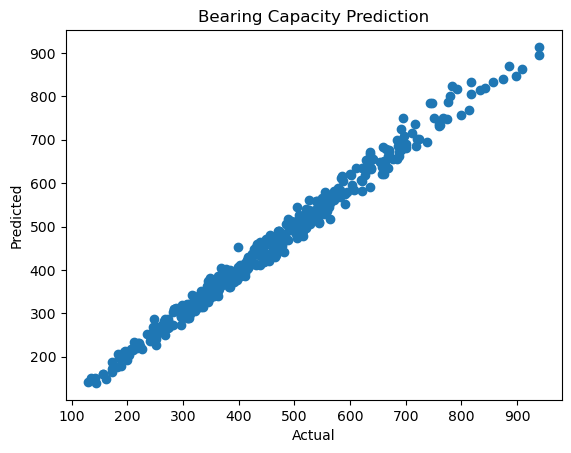

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Bearing Capacity Prediction")
plt.show()

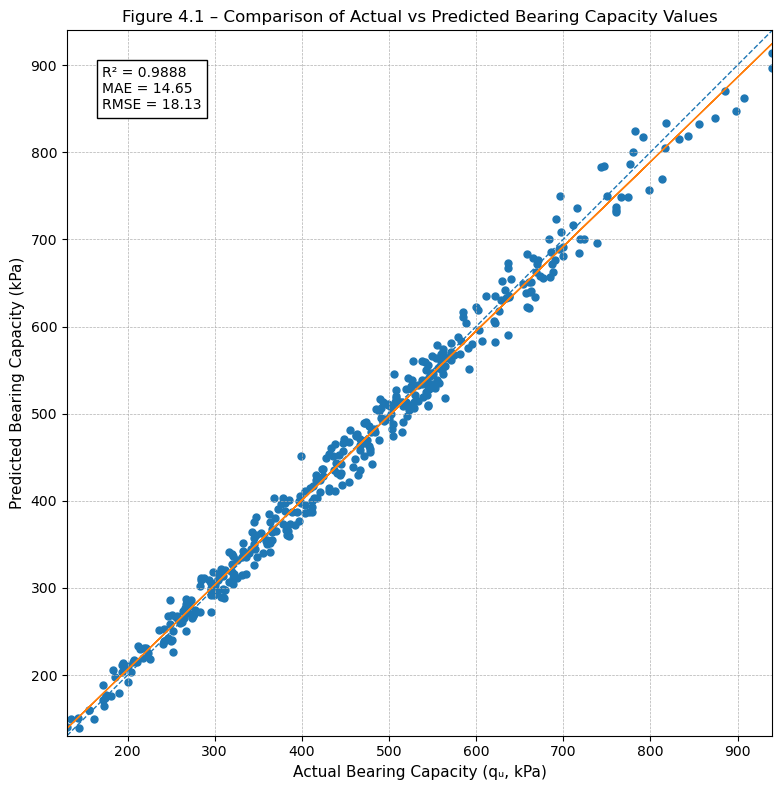

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming you already have:
# y_test (Actual values)
# y_pred (Predicted values)

# Metrics (use yours directly or recompute)
MAE = 14.652781103463798
RMSE = 18.125048268537
R2 = 0.9887744799683666

# Create figure
plt.figure(figsize=(8, 8))


# Scatter plot (DO NOT CHANGE STYLE MUCH)
plt.scatter(y_test, y_pred, s=25)

# Perfect prediction line (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 
         linestyle='--', linewidth=1)

# Optional: Best-fit regression line
coeffs = np.polyfit(y_test, y_pred, 1)
reg_line = np.poly1d(coeffs)
plt.plot(y_test, reg_line(y_test), linewidth=1)

# Labels
plt.xlabel('Actual Bearing Capacity (qᵤ, kPa)', fontsize=11)
plt.ylabel('Predicted Bearing Capacity (kPa)', fontsize=11)
plt.title('Figure 4.1 – Comparison of Actual vs Predicted Bearing Capacity Values', fontsize=12)

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')

# Grid
plt.grid(True, linestyle='--', linewidth=0.5)

# Metrics annotation box
textstr = '\n'.join((
    f'R² = {R2:.4f}',
    f'MAE = {MAE:.2f}',
    f'RMSE = {RMSE:.2f}'
))

plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(facecolor='white'))

plt.tight_layout()
plt.savefig('Comparison bearing capacity', dpi=300, bbox_inches='tight')
plt.show()


### Error Distribution

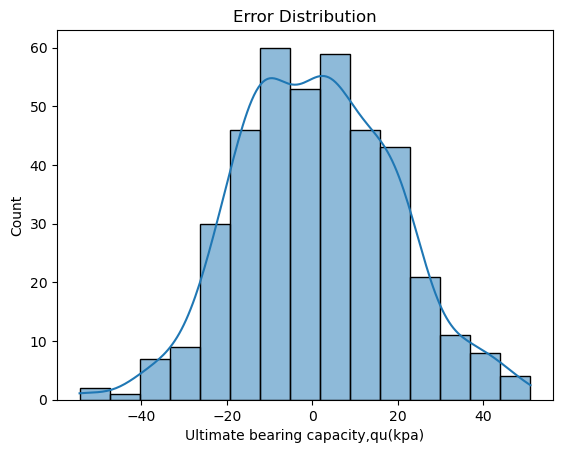

In [19]:
errors = y_test - y_pred
sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()

## Feature Importance Analysis

### Feature Importance Analysis

---

#### Definition

Feature importance analysis measures how much each input variable (feature) contributes to the predictive power of a machine learning model.  

It helps identify which features are most influential in making predictions.

---

#### Methods of Computing Feature Importance

1. **Tree-based Models (Random Forest, XGBoost, Decision Trees):**  
   - Importance is based on how much each feature decreases the impurity (e.g., Gini or entropy) across all trees.  
   - Features that frequently split the data effectively get higher scores.

2. **Permutation Importance:**  
   - Randomly shuffle the values of one feature and measure how much the model’s performance decreases.  
   - A larger drop indicates a more important feature.

3. **Coefficient Magnitude (Linear Models):**  
   - In linear regression or logistic regression, the absolute value of the feature coefficient indicates its importance.  
   - Higher absolute values → more influence on predictions.

---

#### Interpretation

- High importance → the model relies heavily on this feature to make predictions.  
- Low importance → the feature has little effect on the output.  
- Can be used for **feature selection**, **dimensionality reduction**, or **understanding the model**.

---

#### Example: Random Forest Feature Importance

Suppose we trained a Random Forest to predict house prices with features: `Size`, `Location`, `Bedrooms`, `Age`.

| Feature     | Importance Score |
|------------|----------------|
| Size       | 0.45           |
| Location   | 0.30           |
| Bedrooms   | 0.15           |
| Age        | 0.10           |

Interpretation: `Size` is the most important factor, followed by `Location`. `Age` has the least impact.

---

#### Use Case

- Helps **prune unimportant features** to reduce model complexity.  
- Improves **model interpretability** for stakeholders.  
- Identifies **key drivers** of predictions in business or research contexts.

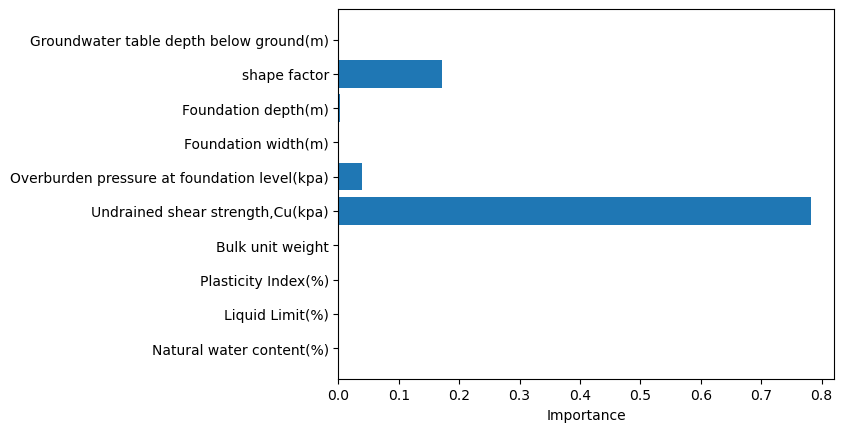

In [17]:
importance = rf.feature_importances_
features_0 = features.columns

plt.barh(features_0, importance)
plt.xlabel("Importance")
plt.show()

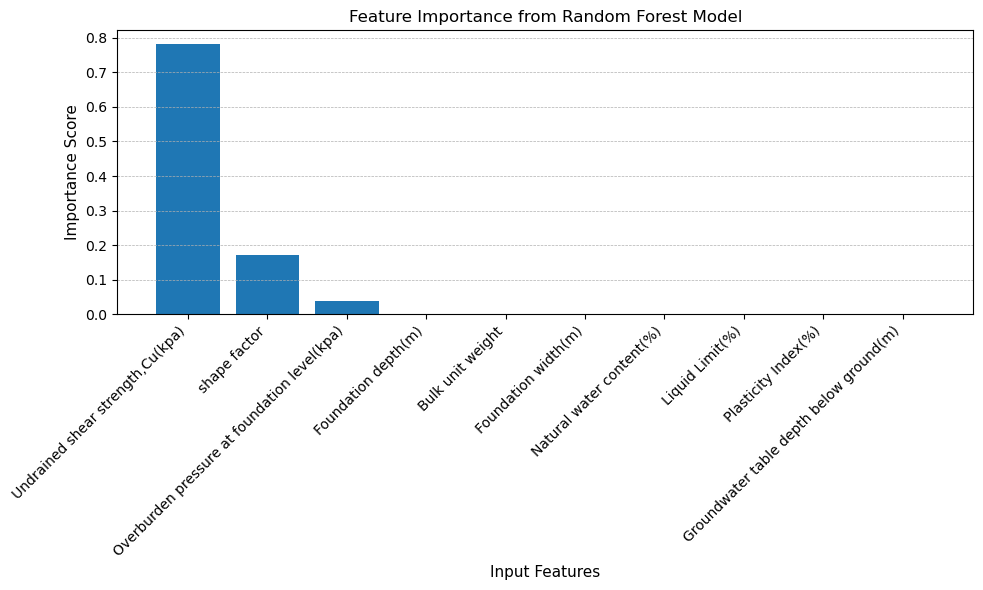

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature importances

importances = rf.feature_importances_

# Feature names (VERY IMPORTANT: must match your dataset columns)
feature_names = features.columns

# Sort features (descending importance)
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart
ax.bar(range(len(sorted_importances)), sorted_importances)

# Labels and title
ax.set_title('Feature Importance from Random Forest Model', fontsize=12)
ax.set_xlabel('Input Features', fontsize=11)
ax.set_ylabel('Importance Score', fontsize=11)

# X ticks
ax.set_xticks(range(len(sorted_features)))
ax.set_xticklabels(sorted_features, rotation=45, ha='right')

# Grid
ax.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Tight layout
plt.tight_layout()

# Save figure (VERY IMPORTANT)
fig.savefig('Figure_4_2_Feature_Importance.png', dpi=300, bbox_inches='tight')
fig.savefig('Figure_4_2_Feature_Importance.pdf', bbox_inches='tight')

# Show
plt.show()

## Comparison of Machine Learning Algorithms for Bearing Capacity Prediction

To evaluate the performance of the Random Forest (RF) model, it is compared with other machine learning algorithms including Artificial Neural Networks (ANN), Support Vector Regression (SVR), and Stochastic Gradient Descent Regression (SGD).

### Artificial Neural Networks (ANN)
Artificial Neural Networks (ANN) are capable of modeling complex nonlinear relationships between soil parameters and bearing capacity. However, they require large datasets and careful tuning of hyperparameters.

**Advantages:**
- Captures nonlinear relationships
- High predictive capability

**Limitations:**
- Requires large datasets
- Computationally expensive
- Less interpretable

---

### Support Vector Regression (SVR)
SVR maps input data into a higher-dimensional space and fits a regression model. It performs well for small datasets but is sensitive to parameter tuning.

**Advantages:**
- Effective in high-dimensional spaces
- Good generalization ability

**Limitations:**
- Slow for large datasets
- Sensitive to kernel parameters

---

### Stochastic Gradient Descent (SGD)
SGD is a fast and efficient linear model suitable for large datasets. However, it struggles with nonlinear relationships common in geotechnical data.

**Advantages:**
- Very fast
- Memory efficient

**Limitations:**
- Assumes linearity
- Lower accuracy for complex problems

---

### Random Forest (RF)
Random Forest is an ensemble model that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

**Advantages:**
- Handles nonlinear relationships well
- Robust and accurate
- Provides feature importance

---

### Summary Table

| Model | Nonlinearity | Interpretability | Speed | Accuracy |
|------|-------------|----------------|-------|---------|
| ANN  | High        | Low            | Medium| High    |
| SVR  | Medium      | Medium         | Low   | High    |
| SGD  | Low         | High           | Very High | Low |
| RF   | High        | Medium         | High  | Very High |

**Conclusion:** Random Forest generally performs better for bearing capacity prediction due to its ability to model complex soil behavior effectively.

In [21]:

from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



rf
ann = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

models = {
    "Random Forest": rf,
    "ANN": ann,
    "SVR": svr,
    "SGD": sgd
}

results = []



for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2 Score"])
print(results_df)


           Model       RMSE  R2 Score
0  Random Forest  18.125048  0.988774
1            ANN  16.359997  0.990854
2            SVR  23.482412  0.981158
3            SGD  27.542354  0.974079


### Monte Carlo Simulation for Bearing Capacity Prediction

Monte Carlo simulation was used to incorporate uncertainty into the prediction of ultimate bearing capacity of soils. This probabilistic approach involves generating a large number of random samples of input parameters and evaluating their effect on the predicted output.

In this study, key geotechnical parameters such as natural water content, liquid limit, plasticity index, bulk unit weight, undrained shear strength, overburden pressure, foundation width and depth, shape factor, and groundwater table depth were treated as random variables. These variables were assumed to follow a normal distribution defined by their mean ($\mu$) and standard deviation ($\sigma$).

Random samples of each parameter were generated using:

$$
X_i = \mu_i + \sigma_i Z
$$

where $X_i$ is the simulated value, $\mu_i$ is the mean, $\sigma_i$ is the standard deviation, and $Z$ is a standard normal random variable.

For each simulation, the generated input values were passed into the trained Random Forest model to predict the ultimate bearing capacity ($q_u$). This process was repeated for a large number of simulations ($N$), producing a distribution of predicted values.

The results were evaluated using statistical measures such as:

$$
\bar{q}_u = \frac{1}{N} \sum_{i=1}^{N} q_{u,i}
$$

$$
\sigma_{q_u} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (q_{u,i} - \bar{q}_u)^2}
$$

where $q_{u,i}$ is the predicted bearing capacity for each simulation.

Monte Carlo simulation provides a more realistic assessment of soil behavior by accounting for variability and uncertainty in input parameters.

Monte Carlo Simulation Results:
Mean Bearing Capacity: 890.92 kPa
Standard Deviation: 43.07
5th Percentile: 883.53
Median: 900.54
95th Percentile: 901.04


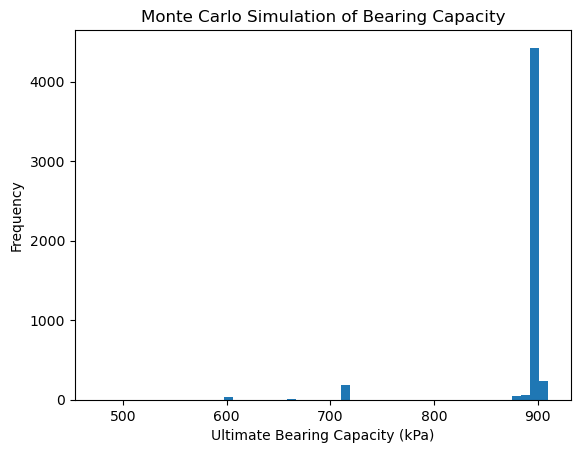

In [30]:


# ===============================
# Monte Carlo Simulation
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_simulations = 5000

simulated_results = []

# Define features properly
Input_features = dataset.columns[:-1]
Output_feature = dataset.columns[-1]

X = dataset[Input_features]

# Correct mean and std
means = X.mean()
stds = X.std()

for i in range(n_simulations):
    sample = {}

    for col in Input_features:
        sample[col] = max(0, np.random.normal(means[col], stds[col]))

    # Keep column order consistent
    sample_df = pd.DataFrame([sample])[Input_features]
    
    prediction = rf.predict(sample_df.values)[0]

    

    simulated_results.append(prediction)

simulated_results = np.array(simulated_results)

# -------------------------------
# Results
# -------------------------------
mean_qu = np.mean(simulated_results)
std_qu = np.std(simulated_results)
p5 = np.percentile(simulated_results, 5)
p50 = np.percentile(simulated_results, 50)
p95 = np.percentile(simulated_results, 95)

print("Monte Carlo Simulation Results:")
print(f"Mean Bearing Capacity: {mean_qu:.2f} kPa")
print(f"Standard Deviation: {std_qu:.2f}")
print(f"5th Percentile: {p5:.2f}")
print(f"Median: {p50:.2f}")
print(f"95th Percentile: {p95:.2f}")

# -------------------------------
# Plot
# -------------------------------
plt.hist(simulated_results, bins=50)
plt.title("Monte Carlo Simulation of Bearing Capacity")
plt.xlabel("Ultimate Bearing Capacity (kPa)")
plt.ylabel("Frequency")
plt.show()

In [26]:
dataset.columns[-1]

'Ultimate bearing capacity,qu(kpa)'

## 2.10.4 Reliability Analysis and Integration into Design

Reliability-based design in geotechnical engineering involves treating loads and resistances as random variables and computing the probability of failure ($P_f$) or reliability index ($\beta$).

The reliability index $\beta$ is defined by the First-Order Second-Moment (FOSM) method as:

$$
\beta = \frac{\mu_R - \mu_S}{\sqrt{\sigma_R^2 + \sigma_S^2}}
$$

where:

- $\mu_R, \sigma_R$ are the mean and standard deviation of resistance  
- $\mu_S, \sigma_S$ are the mean and standard deviation of load  

---

A limit-state function is defined as:

$$
g(X) = R - S
$$

where:

- $R$ = resisting capacity  
- $S$ = applied load (demand)

Failure occurs when:

$$
g(X) < 0 \quad \text{or equivalently} \quad R < S
$$

---

The probability of failure is given by:

$$
P_f = P(g(X) < 0) = P(R < S)
$$

---

For normally distributed variables, the relationship between reliability index and probability of failure is:

$$
P_f = \Phi(-\beta)
$$

where $\Phi(\cdot)$ is the cumulative distribution function (CDF) of the standard normal distribution.

---

In general cases where the distributions are non-Gaussian, the probability of failure is evaluated using Monte Carlo Simulation (MCS) as:

$$
P_f \approx \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(R_i < S_i)
$$

where:

- $N$ is the number of simulations  
- $\mathbb{I}(\cdot)$ is the indicator function, equal to 1 when $R_i < S_i$ and 0 otherwise  

---

In this study, the resistance $R$ is obtained from predictions of the machine learning model (Random Forest), while uncertainty in both the model predictions and input variables is propagated using Monte Carlo Simulation. The load $S$ is modeled as a random variable based on assumed or observed variability.

This approach enables the quantification of uncertainty in geotechnical design and provides a probabilistic measure of safety through $P_f$ and $\beta$, supporting reliability-based decision-making.

In [31]:
import numpy as np
from scipy.stats import norm

# --------------------------------------------------
# Inputs (from your trained ML model + assumptions)
# --------------------------------------------------

# Example: Replace this with your trained RF model
# model.predict(X)

def model_predict(X):
    
    return rf.predict(X)  


# Number of Monte Carlo simulations
n_simulations = 5000

# --------------------------------------------------
# Step 1: Define Input Uncertainty
# --------------------------------------------------

means = means = np.array([
    25,   # Natural water content
    45,   # Liquid Limit
    20,   # Plasticity Index
    18,   # Bulk unit weight
    80,   # Cu (kPa)
    150,  # Overburden pressure
    2.5,  # Foundation width
    1.5,  # Foundation depth
    1.2,  # Shape factor
    3.0   # Groundwater depth
])
stds = np.array([
    5,
    8,
    4,
    1,
    20,
    30,
    0.5,
    0.3,
    0.2,
    1.0
])

# Generate random samples of input variables
X_samples = np.random.normal(means, stds, (n_simulations, len(means)))

# --------------------------------------------------
# Step 2: Predict Resistance (R)
# --------------------------------------------------

R_samples = model_predict(X_samples)

# If model_predict returns scalar per row, ensure shape consistency:
R_samples = np.array(R_samples).flatten()

# --------------------------------------------------
# Step 3: Define Load (S) Uncertainty
# --------------------------------------------------

# Load (Demand) Distribution
# --------------------------------------------------
# --------------------------------------------------
# Load (Demand) Distribution
# --------------------------------------------------
S_mean = 50
S_std = 10

S_samples = np.random.normal(S_mean, S_std, n_simulations)

# --------------------------------------------------
# Limit State Function
# g(X) = R - S
# --------------------------------------------------
g = R_samples - S_samples

# Failure condition
failure = g < 0

# --------------------------------------------------
# Probability of Failure (Pf)
# --------------------------------------------------
Pf = np.mean(failure)

# Avoid numerical issues
Pf = max(Pf, 1e-10)

# --------------------------------------------------
# Reliability Index (β)
# --------------------------------------------------
beta = -norm.ppf(Pf)

# --------------------------------------------------
# Output
# --------------------------------------------------
print("----- RELIABILITY ANALYSIS RESULTS -----")
print(f"Probability of Failure (Pf): {Pf:.6f}")
print(f"Reliability Index (β): {beta:.4f}")

----- RELIABILITY ANALYSIS RESULTS -----
Probability of Failure (Pf): 0.000000
Reliability Index (β): 6.3613


The computed probability of failure was approximately zero, corresponding to a reliability index of β = 6.36. This indicates that the predicted resistance significantly exceeds the applied load under the assumed variability, implying a highly reliable and conservative system. The high reliability index suggests that the probability of structural or geotechnical failure is extremely low.

#### Comparision with Terzaghi bearing capacity 

For pure clay, where the internal friction angle $\phi = 0^\circ$, the Terzaghi bearing capacity factors are:

$$
N_q = 1, \quad
N_\gamma = 0, \quad
N_c = 5.14
$$

These values are derived as follows:

$$
\begin{aligned}
N_q &= e^{\pi \tan \phi} \, \tan^2 \left( 45^\circ + \frac{\phi}{2} \right) = 1 \quad (\phi = 0^\circ) \\
N_\gamma &= 2 (N_q + 1) \, \tan \phi = 0 \quad (\phi = 0^\circ) \\
N_c &= \frac{N_q - 1}{\tan \phi} \approx 5.14 \quad (\text{Terzaghi approximation for } \phi = 0^\circ)
\end{aligned}
$$

In [10]:
dataset.columns

Index(['Natural water content(%)', 'Liquid Limit(%)', 'Plasticity Index(%)',
       'Bulk unit weight', 'Undrained shear strength,Cu(kpa)',
       'Overburden pressure at foundation level(kpa)', 'Foundation width(m)',
       'Foundation depth(m)', 'shape factor',
       'Groundwater table depth below ground(m)',
       'Ultimate bearing capacity,qu(kpa)'],
      dtype='object')

X_SAMPLE [[ 68.89010274  58.28748899  35.59201024  17.36024869  53.82983003
  114.84846967   2.81107523   0.52534003   0.7          3.2748033 ]]
target 293.88028251461463
ML Predicted Bearing Capacity (kPa): 901.3492043728102
Terzaghi Bearing Capacity (kPa): 315.950064766522


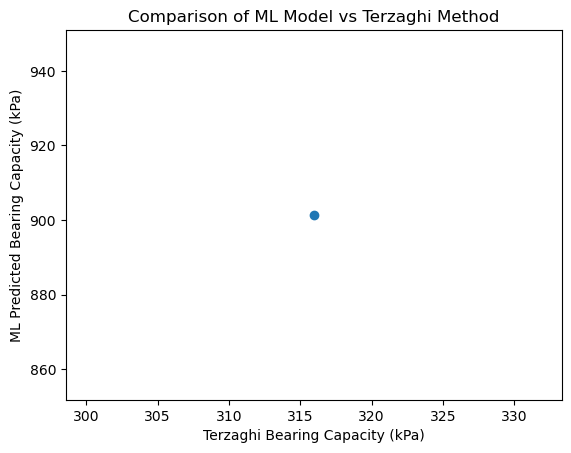

In [112]:
import numpy as np

# -----------------------------
# Bearing Capacity Factors
# -----------------------------
def bearing_capacity_factors(phi):
    phi_rad = np.radians(phi)

    Nq = np.exp(np.pi * np.tan(phi_rad)) * (np.tan(np.pi/4 + phi_rad/2)**2)
    Nc = (Nq - 1) / np.tan(phi_rad)
    Ngamma = 2 * (Nq + 1) * np.tan(phi_rad)

    return Nc, Nq, Ngamma


# -----------------------------
# Terzaghi Bearing Capacity
# -----------------------------
def terzaghi_bearing_capacity(c, gamma, Df, B):
    Nc, Nq, Ngamma = (5.7, 1, 0)

    qu = (c * Nc) + (gamma * Df)

    return qu
row_number = 777
inputs = inputvalues(row_number)

qu_terzaghi = terzaghi_bearing_capacity(
    inputs['c'],
    inputs['gamma'],
    inputs['Df'],
    inputs['B'],
   
)
X_sample = features.iloc[row_number].values
X_sample = X_sample.reshape(1, -1)

scaler.fit_transform(X_train)
X_sample = scaler.transform(X_sample )





# reshape to 2D


print("X_SAMPLE",X_sample)
print("target",target)


qu_ml = rf.predict(X_sample.reshape(1, -1))[0]

print("ML Predicted Bearing Capacity (kPa):", qu_ml)
print("Terzaghi Bearing Capacity (kPa):", qu_terzaghi)

inputvalues(row_number)

import matplotlib.pyplot as plt

plt.scatter([qu_terzaghi], [qu_ml])
plt.xlabel("Terzaghi Bearing Capacity (kPa)")
plt.ylabel("ML Predicted Bearing Capacity (kPa)")
plt.title("Comparison of ML Model vs Terzaghi Method")
plt.show()

In [109]:
X_sample = dataset[features].iloc[row_number].values

ValueError: Boolean array expected for the condition, not float64

In [81]:
dataset.iloc[500]

Natural water content(%)                         67.926469
Liquid Limit(%)                                  91.375946
Plasticity Index(%)                              61.393464
Bulk unit weight                                 16.603526
Undrained shear strength,Cu(kpa)                 78.061604
Overburden pressure at foundation level(kpa)     15.215543
Foundation width(m)                               2.516787
Foundation depth(m)                               1.622838
shape factor                                      0.700000
Groundwater table depth below ground(m)           3.334264
Ultimate bearing capacity,qu(kpa)               303.888033
Name: 501, dtype: float64

In [62]:
X_sample = features.values[0]
print(X_sample)


[ 54.98160475  63.08528419  33.78538723  17.94477086 115.03349049
  62.30971459   2.1357658    0.60976265   1.           1.22548686]


In [50]:
def inputvalues(row_number):
    row = dataset.iloc[row_number]

    tergazhi_list = [
        "Undrained shear strength,Cu(kpa)",
        "Bulk unit weight",
        "Foundation depth(m)",
        "Foundation width(m)"
    ]

    # Correct mapping between dataset columns and dictionary keys
    key_map = {
        "Undrained shear strength,Cu(kpa)": "c",
        "Bulk unit weight": "gamma",
        "Foundation depth(m)": "Df",
        "Foundation width(m)": "B"
    }

    input_to_values = {"c": 0, "gamma": 0, "Df": 0, "B": 0}

    for col in tergazhi_list:
        value = row[col]
        key = key_map[col]

        
        input_to_values[key] = float(value)
        

    return input_to_values


In [113]:
dataset.iloc[0]

Natural water content(%)                         54.981605
Liquid Limit(%)                                  63.085284
Plasticity Index(%)                              33.785387
Bulk unit weight                                 17.944771
Undrained shear strength,Cu(kpa)                115.033490
Overburden pressure at foundation level(kpa)     62.309715
Foundation width(m)                               2.135766
Foundation depth(m)                               0.609763
shape factor                                      1.000000
Groundwater table depth below ground(m)           1.225487
Ultimate bearing capacity,qu(kpa)               656.543650
Name: 1, dtype: float64

In [115]:
X_train[0]

array([ 0.24055809,  1.60776651,  0.71494735,  0.60902376,  0.2802845 ,
        0.52984907,  0.44345317, -0.28375379,  1.43450707, -1.40176001])

115.03349049342444